In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
### Read in CSV file
file_id = "1mMFM2r9djuERbeCDMvow3SdKoYOGcH9b"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)

In [7]:
df = df.sort_values(by="Payroll", ascending=False)
df.head()

,Year,Team,Payroll,Wins,Losses,Games,Win_Pct,MLB_Avg_Payroll,Relative_Payroll,Payroll_Rank,Payroll_Per_Win,Wins_Above_81,Payroll_Above_Avg,Payroll_Source_Definition
60,2023,New York Mets,334233332,75,87,162,0.4630,148380474,2.2525,1,4456444,-6,185852858,Opening Day team payroll
120,2025,Los Angeles Dodgers,331013580,93,69,162,0.5741,169177221,1.9566,1,3559286,12,161836359,Opening Day team payroll
121,2025,New York Mets,321594220,83,79,162,0.5123,169177221,1.9009,2,3874629,2,152416999,Opening Day team payroll
90,2024,New York Mets,307792124,89,73,162,0.5494,163552389,1.8819,1,3458338,8,144239735,Opening Day team payroll
91,2024,New York Yankees,305444574,94,68,162,0.5802,163552389,1.8676,2,3249410,13,141892185,Opening Day team payroll


In [8]:
df.dtypes

Year                           int64
Team                             str
Payroll                        int64
Wins                           int64
Losses                         int64
Games                          int64
Win_Pct                      float64
MLB_Avg_Payroll                int64
Relative_Payroll             float64
Payroll_Rank                   int64
Payroll_Per_Win                int64
Wins_Above_81                  int64
Payroll_Above_Avg              int64
Payroll_Source_Definition        str
dtype: object

In [9]:
df = df.astype({
    "Payroll": "float64",
    "MLB_Avg_Payroll": "float64",
    "Relative_Payroll": "float64",
    "Payroll_Per_Win": "float64",
    "Payroll_Above_Avg": "float64",
})
df.describe()

,Year,Payroll,Wins,Losses,Games,Win_Pct,MLB_Avg_Payroll,Relative_Payroll,Payroll_Rank,Payroll_Per_Win,Wins_Above_81,Payroll_Above_Avg
count,150.000000,1.500000e+02,150.000000,150.000000,150.000000,150.000000,1.500000e+02,150.000000,150.000000,1.500000e+02,150.000000,1.500000e+02
mean,2023.000000,1.497296e+08,80.986667,80.986667,161.973333,0.500007,1.497296e+08,1.000003,15.500000,1.847160e+06,-0.013333,3.333333e-02
std,1.418951,6.706348e+07,13.157276,13.167474,0.161647,0.081257,1.527639e+07,0.434394,8.684438,7.627244e+05,13.157276,6.530040e+07
min,2021.000000,3.254833e+07,41.000000,51.000000,161.000000,0.253100,1.275049e+08,0.232400,1.000000,4.990500e+05,-40.000000,-1.074846e+08
25%,2022.000000,9.797866e+07,74.000000,72.000000,162.000000,0.456800,1.400329e+08,0.647350,8.000000,1.214161e+06,-7.000000,-5.596839e+07
50%,2023.000000,1.420476e+08,82.000000,80.000000,162.000000,0.506200,1.483805e+08,0.981600,15.500000,1.801506e+06,1.000000,-2.677486e+06
75%,2024.000000,1.919921e+08,90.000000,88.000000,162.000000,0.555600,1.635524e+08,1.330825,23.000000,2.342322e+06,9.000000,4.751110e+07
max,2025.000000,3.342333e+08,111.000000,121.000000,162.000000,0.685200,1.691772e+08,2.252500,30.000000,4.456444e+06,30.000000,1.858529e+08


In [10]:
X = df[["Relative_Payroll"]]
y = df["Win_Pct"]

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

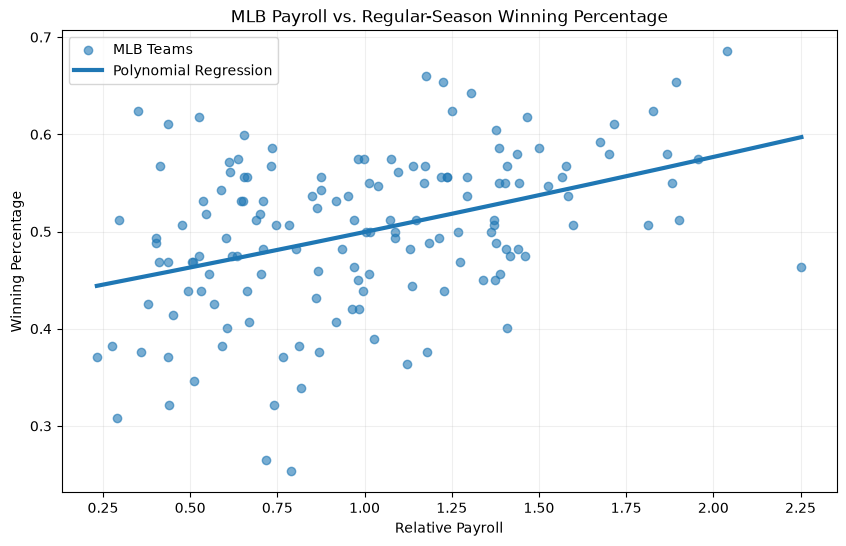

In [11]:
# Create evenly spaced payroll values
X_range = pd.DataFrame({
    "Relative_Payroll": np.linspace(
        X["Relative_Payroll"].min(),
        X["Relative_Payroll"].max(),
        200
    )
})

# Transform values using the polynomial transformation
X_range_poly = poly.transform(X_range)

# Predict winning percentage
y_curve = model.predict(X_range_poly)

# Create plot
plt.figure(figsize=(10, 6))

# Actual observations
plt.scatter(
    X["Relative_Payroll"],
    y,
    alpha=0.6,
    label="MLB Teams"
)

# Polynomial regression curve
plt.plot(
    X_range["Relative_Payroll"],
    y_curve,
    linewidth=3,
    label="Polynomial Regression"
)

plt.xlabel("Relative Payroll")
plt.ylabel("Winning Percentage")
plt.title("MLB Payroll vs. Regular-Season Winning Percentage")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

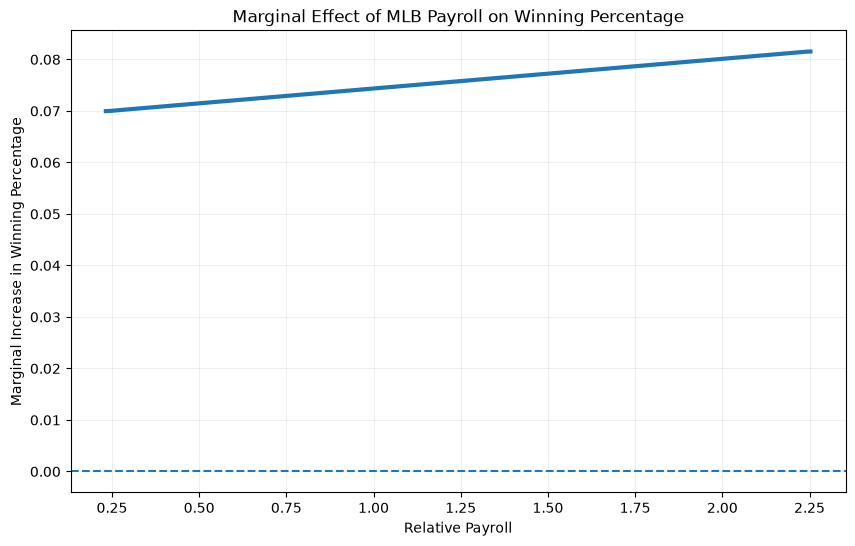

In [13]:
# Create payroll values across your observed range
payroll_range = np.linspace(
    df["Relative_Payroll"].min(),
    df["Relative_Payroll"].max(),
    200
)

X_range = pd.DataFrame({
    "Relative_Payroll": payroll_range
})

# Predict winning percentage
X_poly = poly.transform(X_range)
predicted_win_pct = model.predict(X_poly)

# Calculate marginal return
marginal_return = np.gradient(
    predicted_win_pct,
    payroll_range
)

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    payroll_range,
    marginal_return,
    linewidth=3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Relative Payroll")
plt.ylabel("Marginal Increase in Winning Percentage")
plt.title("Marginal Effect of MLB Payroll on Winning Percentage")

plt.grid(alpha=0.2)

plt.show()

In [16]:
# Predictions from your polynomial regression model
y_pred = model.predict(X_poly)

# Model metrics
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("Polynomial Regression Metrics")
print("-----------------------------")
print(f"R²:  {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.6f}")

Polynomial Regression Metrics
-----------------------------
R²:  0.1603
MAE: 0.0593
MSE: 0.005507
